In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from itertools import cycle
import medmnist
from medmnist import INFO

In [2]:
filename = './PathMNIST_ResNet18/pathmnist/260218_201047/pathmnist_test_[AUC]0.978_[ACC]0.899@model1.csv' 

info = INFO['pathmnist']
DataClass = getattr(medmnist, info['python_class'])
test_dataset = DataClass(split='test', download=True)

df = pd.read_csv(filename, header=None)

In [3]:
y_score = df.iloc[:, 1:].values 
n_classes = y_score.shape[1]

y_test = np.array([label[0] for _, label in test_dataset])
y_test_bin = label_binarize(y_test, classes=range(n_classes))

In [4]:
fpr = dict()
tpr = dict()
roc_auc = dict()

# Calculate ROC for each individual class
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

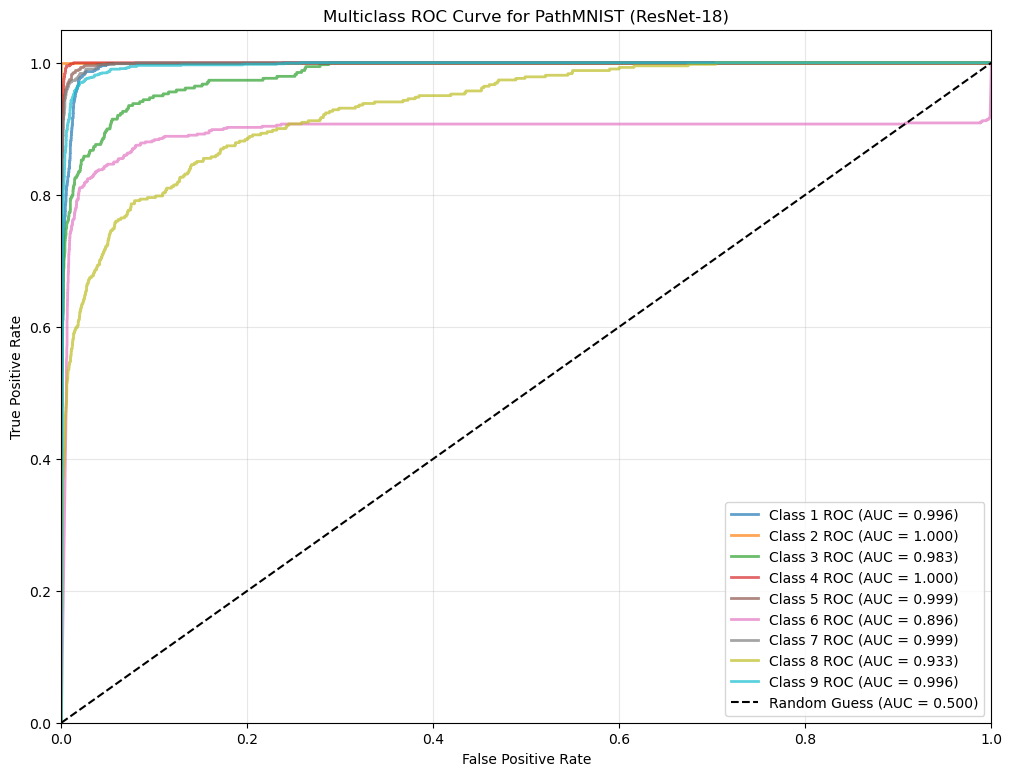

In [5]:
plt.figure(figsize=(12, 9))

cmap = plt.colormaps.get_cmap('tab10')
colors = cycle([cmap(i) for i in np.linspace(0, 1, n_classes)])

for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2, alpha=0.7,label=f'Class {i+1} ROC (AUC = {roc_auc[i]:.3f})')


plt.plot([0, 1], [0, 1], 'k--', label='Random Guess (AUC = 0.500)') # Random guessing diagonal

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multiclass ROC Curve for PathMNIST (ResNet-18)')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)

output_file = 'Test_roc_curve.png'
plt.savefig(output_file, dpi=300, bbox_inches='tight')
plt.show()

In [6]:
output_file = 'Test_roc_curve.png'
plt.savefig(output_file, dpi=300, bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

In [7]:
# finding correct prediction images:
y_pred = np.argmax(y_score, axis=1)

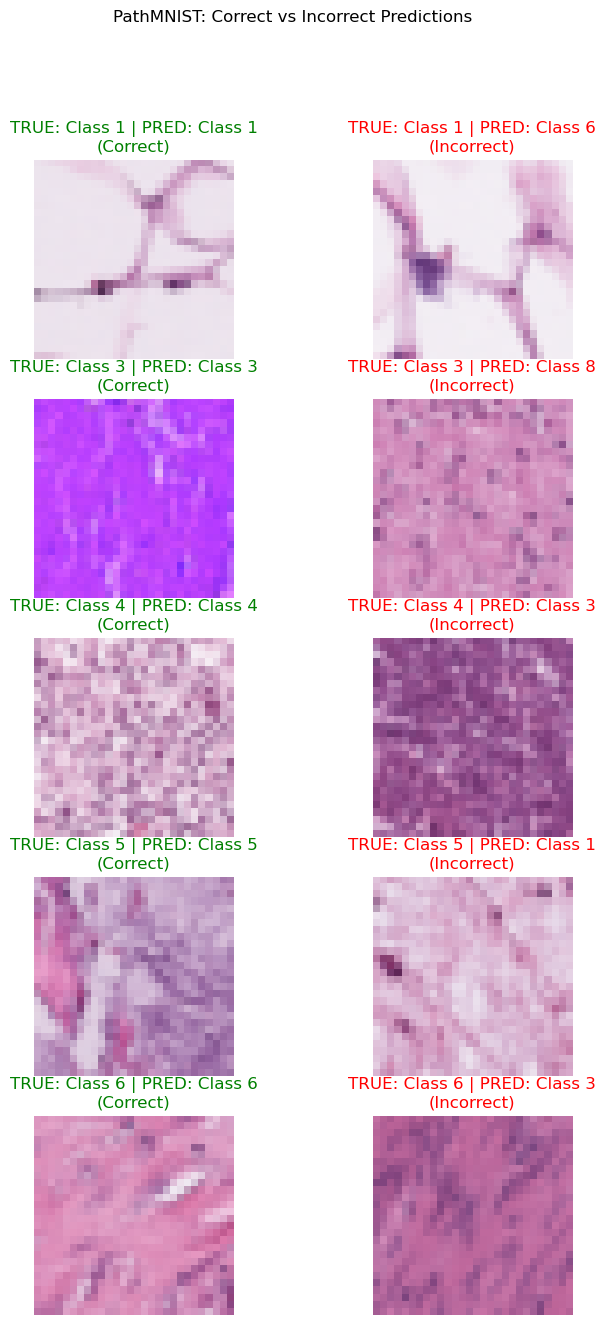

In [8]:
classes_to_plot = [0, 2, 3, 4, 5]

fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(8, 15))
fig.suptitle('PathMNIST: Correct vs Incorrect Predictions')

for i, cls in enumerate(classes_to_plot):
    correct_indices = np.where((y_test == cls) & (y_pred == cls))[0]
    incorrect_indices = np.where((y_test == cls) & (y_pred != cls))[0]
    
    # Correct Example
    if len(correct_indices) > 0:
        idx_c = correct_indices[0]
        img_c, _ = test_dataset[idx_c]
        axes[i, 0].imshow(img_c)
        axes[i, 0].set_title(f"TRUE: Class {cls + 1} | PRED: Class {cls + 1}\n(Correct)", color='green')
    axes[i, 0].axis('off')

    # Incorrect Example
    if len(incorrect_indices) > 0:
        idx_i = incorrect_indices[0]
        img_i, _ = test_dataset[idx_i]
        wrong_pred = y_pred[idx_i]
        axes[i, 1].imshow(img_i)
        axes[i, 1].set_title(f"TRUE: Class {cls + 1} | PRED: Class {wrong_pred + 1}\n(Incorrect)", color='red')
    axes[i, 1].axis('off')
    
output_img = 'classification_examples.png'
plt.savefig(output_img, dpi=300)
plt.show()

In [9]:
output_img = 'classification_examples.png'
plt.savefig(output_img, dpi=300)

<Figure size 640x480 with 0 Axes>